\
# Exercice — Physics-Informed ML (sklearn)
## Régression quadratique + contrainte physique

On modélise :
$$
f(x)=ax^2+bx+c
$$

- **Régression classique** : minimiser la MSE sur les données.
- **Physics-Informed** : minimiser  
$$
\mathcal L = \text{MSE}_{data} + \lambda\,\mathbb E[(f''(x))^2]
$$


---

## Plan (à faire)
1. Réaliser la régression classique (MSE data).
2. Visualiser la régression classique.
3. Ajouter la contrainte physique avec un $\lambda$.
4. Visualiser la régression contrainte.
5. Faire varier $\lambda$ et comparer.

> **Consigne** : la génération de données est déjà faite (ne pas modifier).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)


\
## Génération des données (déjà faite — ne pas modifier)

- Groupe 1 : $ (x\in[0,10]) $, cible $ (y=2x+3) $ (avec bruit)
- Groupe 2 : même nombre de points autour de $(x=-10, y=15)$ (avec bruit)


In [3]:
# Taille de chaque groupe
N = 3000

# Groupe principal : y = 2x + 3 sur [0,10]
x1 = np.sort(rng.uniform(0, 10, size=N))
y1 = 2.0 * x1 + 3.0 + rng.normal(0, 0.8, size=N)

# Groupe perturbateur : autour de (-5, 5)
x2 = rng.normal(-10.0, 0.5, size=10)
y2 = 15.0 + rng.normal(0, 0.8, size=10)

# Dataset complet
x = np.concatenate([x1, x2])
y = np.concatenate([y1, y2])


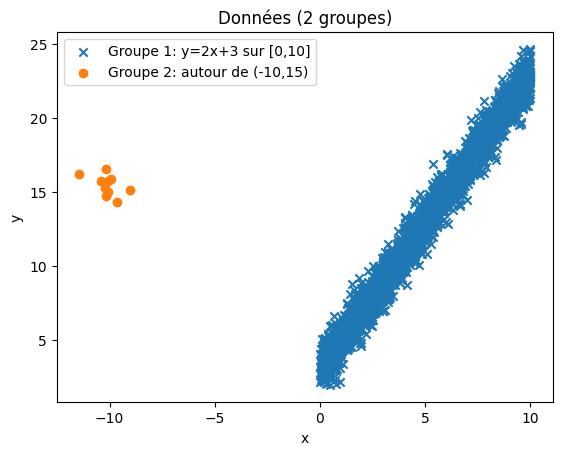

In [4]:
plt.figure()
plt.scatter(x1, y1, marker="x", label="Groupe 1: y=2x+3 sur [0,10]")
plt.scatter(x2, y2, marker="o", label="Groupe 2: autour de (-10,15)")
plt.title("Données (2 groupes)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


\
## Outils : features du modèle et contrainte

- Pour $f(x)=ax^2+bx+c$ : features $[x^2,\;x,\;1]$.

Ces fonctions sont fournies.


In [5]:
def Phi(x):
    # f(x)=ax^2+bx+c -> [x^2, x, 1]·[a,b,c]
    x = np.asarray(x)
    return np.column_stack([x**2, x, np.ones_like(x)])


\
## 1) Régression classique (MSE sur les données)

À faire :
- Construire `X_data = Phi(x)`
- Entraîner une régression linéaire `LinearRegression(fit_intercept=False)`
- Afficher les coefficients $a,b,c$ et la MSE data


In [6]:
# 1) Régression classique (MSE sur les données)
X_data = Phi(x)
model = LinearRegression(fit_intercept=False)
model.fit(X_data, y)
a, b, c = model.coef_
y_pred = model.predict(X_data)
mse_data = mean_squared_error(y, y_pred)
print(f"Coefficients: a={a:.4f}, b={b:.4f}, c={c:.4f}")
print(f"MSE sur les données: {mse_data:.4f}")

Coefficients: a=0.1086, b=0.8578, c=5.1223
MSE sur les données: 1.4611


\
## 2) Visualiser la régression classique

À faire :
- Créer une grille `xx` sur [-11, 11]
- Tracer les données
- Tracer la droite "vérité" du groupe 1 : `y = 2x + 3`
- Tracer la prédiction du modèle classique


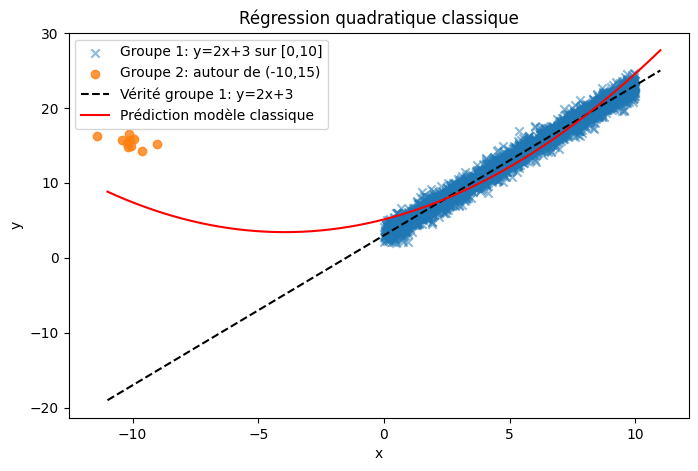

In [24]:
# 2) Visualiser la régression classique
xx = np.linspace(-11, 11, 300)
yy_true = 2 * xx + 3
yy_pred = Phi(xx) @ model.coef_
plt.figure(figsize=(8,5))
plt.scatter(x1, y1, marker="x", label="Groupe 1: y=2x+3 sur [0,10]", alpha=0.5)
plt.scatter(x2, y2, marker="o", label="Groupe 2: autour de (-10,15)", alpha=0.8)
plt.plot(xx, yy_true, 'k--', label='Vérité groupe 1: y=2x+3')
plt.plot(xx, yy_pred, 'r-', label='Prédiction modèle classique')
plt.title("Régression quadratique classique")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

\
## 3) Ajouter la contrainte $f''(x)=0$ avec un $\lambda$

On veut minimiser : MSE_data + λ * mean( (f'')^2 ).

Astuce sklearn : on ajoute des **pseudo-observations** (pondérées) :

- Data : `X_data -> y`
- Physique : `X_phys -> y_phys=0` avec `X_phys = ddPhi(M)`

et on pondère la partie physique par `w = sqrt(lambda_)`.

À faire :
- Choisir `lambda_` (ex: 1.0)
- Construire `X_aug` et `y_aug`
- Entraîner `model_phys` sur `(X_aug, y_aug)`
- Afficher $a,b,c$, MSE_data, et `mean(f'')^2`


In [ ]:
# 3) Régression avec contrainte physique (Physics-Informed)
def ddPhi(x):
    # Dérivée seconde de f(x)=ax^2+bx+c par rapport à x : 2a
    x = np.asarray(x)
    return np.column_stack([np.full_like(x, 2.0), np.zeros_like(x), np.zeros_like(x)])

lambda_ = 1.0
M = 300 # nombre de points pour la contrainte physique
x_phys = np.linspace(-11, 11, M)
X_phys = ddPhi(x_phys)
y_phys = np.zeros(M)

w = np.sqrt(lambda_)
X_aug = np.vstack([X_data, w * X_phys])
y_aug = np.concatenate([y, w * y_phys])

model_phys = LinearRegression(fit_intercept=False)
model_phys.fit(X_aug, y_aug)
a_phys, b_phys, c_phys = model_phys.coef_
y_pred_phys = model_phys.predict(X_data)
mse_data_phys = mean_squared_error(y, y_pred_phys)
mean_dd2 = np.mean((ddPhi(x) @ model_phys.coef_)**2)
print(f"Coefficients contraints: a={a_phys:.4f}, b={b_phys:.4f}, c={c_phys:.4f}")
print(f"MSE sur les données: {mse_data_phys:.4f}")
print(f"Moyenne (f'')^2: {mean_dd2:.4f}")

Coefficients contraints: a=0.1084, b=0.8597, c=5.1202
MSE sur les données: 1.4611
Moyenne (f'')^2: 0.0470


\
## 4) Visualiser la régression avec contrainte

À faire :
- Sur la même figure, tracer :
  - données
  - vérité groupe 1 : $y=2x+3$
  - prédiction du modèle classique
  - prédiction du modèle contraint (λ choisi)


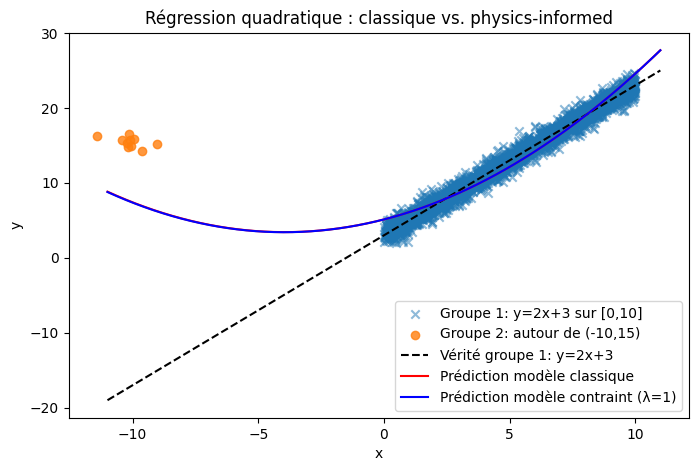

In [26]:
# 4) Visualiser la régression avec contrainte
yy_pred_phys = Phi(xx) @ model_phys.coef_
plt.figure(figsize=(8,5))
plt.scatter(x1, y1, marker="x", label="Groupe 1: y=2x+3 sur [0,10]", alpha=0.5)
plt.scatter(x2, y2, marker="o", label="Groupe 2: autour de (-10,15)", alpha=0.8)
plt.plot(xx, yy_true, 'k--', label='Vérité groupe 1: y=2x+3')
plt.plot(xx, yy_pred, 'r-', label='Prédiction modèle classique')
plt.plot(xx, yy_pred_phys, 'b-', label='Prédiction modèle contraint (λ=1)')
plt.title("Régression quadratique : classique vs. physics-informed")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

\
## 5) Faire varier $\lambda$ et comparer

À faire :
- Définir une liste de lambdas (ex: `[0, 0.01, 0.1, 1, 10, 100]`)
- Pour chaque lambda :
  - entraîner un modèle physics-informed
  - afficher $a,b,c$, MSE_data, mean(f'')^2
- Visualiser les courbes (une par lambda)

Option :
- Tracer aussi une courbe `MSE_data(λ)` et `mean(f'')^2(λ)` en fonction de λ (échelle log).


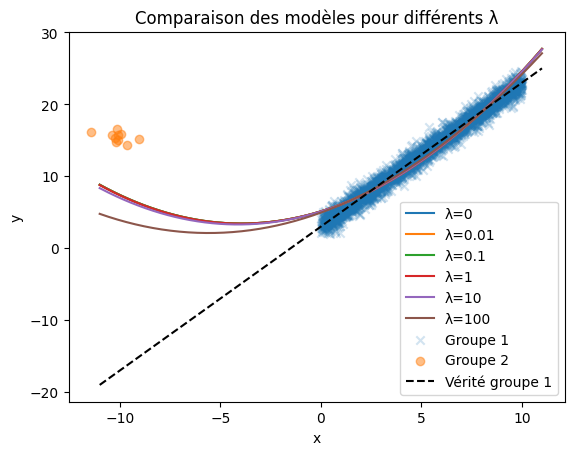

,lambda,a,b,c,MSE_data,mean(f'')^2
0,0.00,0.108599,0.857829,5.122325,1.461104,0.047175
1,0.01,0.108597,0.857847,5.122304,1.461104,0.047173
2,0.10,0.108578,0.858016,5.122113,1.461104,0.047157
3,1.00,0.108388,0.859697,5.120203,1.461113,0.046991
4,10.00,0.106518,0.876185,5.101470,1.461988,0.045384
5,100.00,0.090847,1.014387,4.944454,1.525401,0.033012


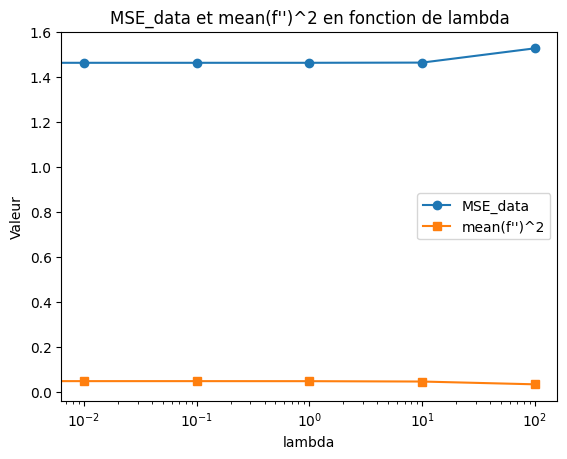

In [27]:
# 5) Faire varier lambda et comparer
lambdas = [0, 0.01, 0.1, 1, 10, 100]
results = []
for lambda_ in lambdas:
    w = np.sqrt(lambda_)
    X_aug = np.vstack([X_data, w * X_phys])
    y_aug = np.concatenate([y, w * y_phys])
    model_l = LinearRegression(fit_intercept=False)
    model_l.fit(X_aug, y_aug)
    coefs = model_l.coef_
    y_pred_l = model_l.predict(X_data)
    mse_data_l = mean_squared_error(y, y_pred_l)
    mean_dd2_l = np.mean((ddPhi(x) @ coefs)**2)
    results.append((lambda_, *coefs, mse_data_l, mean_dd2_l))
    plt.plot(xx, Phi(xx) @ coefs, label=f"λ={lambda_}")
plt.scatter(x1, y1, marker="x", label="Groupe 1", alpha=0.2)
plt.scatter(x2, y2, marker="o", label="Groupe 2", alpha=0.5)
plt.plot(xx, yy_true, 'k--', label='Vérité groupe 1')
plt.title("Comparaison des modèles pour différents λ")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Affichage des résultats
import pandas as pd
df = pd.DataFrame(results, columns=["lambda", "a", "b", "c", "MSE_data", "mean(f'')^2"])
display(df)

plt.figure()
plt.semilogx(df["lambda"], df["MSE_data"], 'o-', label="MSE_data")
plt.semilogx(df["lambda"], df["mean(f'')^2"], 's-', label="mean(f'')^2")
plt.xlabel("lambda")
plt.ylabel("Valeur")
plt.title("MSE_data et mean(f'')^2 en fonction de lambda")
plt.legend()
plt.show()